This notebook takes the work that's been modularised, and turns it into as non-interactive a script as possible, also useful for creating integration tests etc.

In [1]:
# for dev work

import sys
import importlib
# Add src to path (do this once at the top)
sys.path.insert(0, '../../src')

# Initial import
import park_vga

# After editing:
importlib.reload(park_vga.defining_grids)
importlib.reload(park_vga.lidar)
importlib.reload(park_vga)
importlib.reload(park_vga.workflow)

<module 'park_vga.workflow' from '/Users/maeve/Documents/park-vga/notebooks/modularising_the_approach/../../src/park_vga/workflow.py'>

In [2]:
boundaries_file = "../../example_datasets/Leeds_pp_or_g_cmb.geojson"

lidar_dtm = "/Volumes/Extreme SSD/DTM"
lidar_dsm = "/Volumes/Extreme SSD/FZ_DSM"

output_path = "../../outputs/TESTWORKFLOW"

Find the smallest park for rapid testing

In [3]:
park_vga.workflow.find_smallest_park_id(boundaries_file)

(None, 'LEEDS_667fb1455fba', 1047)

In [4]:
park_id = park_vga.workflow.find_park_id(1047, boundaries_file)
print(park_id)

LEEDS_667fb1455fba


In [5]:

park_n = park_vga.workflow.find_park_n("Woodhouse Moor", boundaries_file)

In [6]:
# results = park_vga.workflow.workflow_eng(boundaries_file, park_n, lidar_dtm, lidar_dsm, output_path)

Now check if the loading and saving etc. worked

In [7]:
import geopandas as gpd

visibility_results = gpd.read_file(f"{output_path}/TESTINGWORKFLOW_visibility_results_park_LEEDS_6ddbccbe638c.geojson")

foliage_results = gpd.read_file(f"{output_path}/TESTINGWORKFLOW_foliage_results_park_LEEDS_6ddbccbe638c.geojson")

In [8]:
visibility_results.head()

,visible_points,total_points,visibility_pct,geometry
0,10,132,7.575758,"POLYGON ((-1.55981 53.80806, -1.5599 53.80809,..."
1,8,128,6.250000,"POLYGON ((-1.55964 53.80806, -1.55973 53.80809..."
2,11,123,8.943089,"POLYGON ((-1.55946 53.80806, -1.55955 53.80809..."
3,5,152,3.289474,"POLYGON ((-1.56008 53.80815, -1.56016 53.80818..."
4,0,150,0.000000,"POLYGON ((-1.5599 53.80815, -1.55999 53.80818,..."


<Axes: >

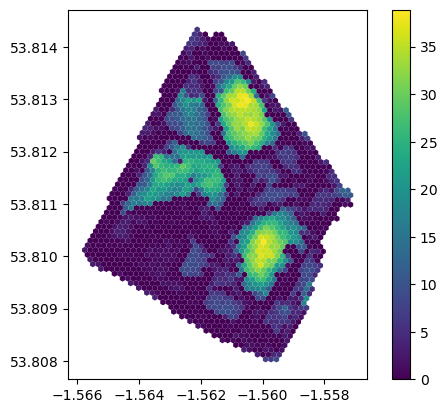

In [9]:
visibility_results.plot(column="visibility_pct", cmap='viridis', legend=True)

In [10]:
foliage_results.head()

,max_height,mean_height,std_height,count_pixels,percent_cover,percent_above_0.1m,low_level_<0.5,mid_level_0.5-2,tall_2+,geometry
0,0.011246,0.000296,0.002317,27,0.024244,0.000000,0.000000,0.000000,0.000000,"POLYGON ((-1.55964 53.80806, -1.55973 53.80809..."
1,10.525497,2.823900,3.366630,30,0.026937,56.666667,0.000000,10.000000,43.333333,"POLYGON ((-1.5599 53.80815, -1.55999 53.80818,..."
2,9.264748,2.580308,3.334008,26,0.023346,80.769231,30.769231,11.538462,34.615385,"POLYGON ((-1.55973 53.80815, -1.55981 53.80818..."
3,12.258995,2.167169,3.024051,28,0.025141,53.571429,3.571429,10.714286,39.285714,"POLYGON ((-1.55955 53.80815, -1.55964 53.80818..."
4,5.737747,1.609071,2.191129,28,0.025141,46.428571,3.571429,14.285714,28.571429,"POLYGON ((-1.56034 53.80824, -1.56043 53.80827..."


<Axes: >

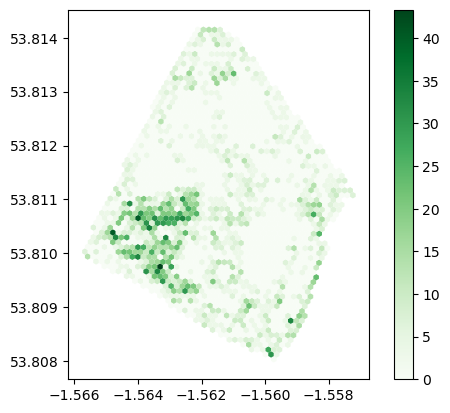

In [11]:
# only show values > 10, make values <10 transparent
foliage_results.plot(column="low_level_<0.5", cmap='Greens', legend=True)

<Axes: >

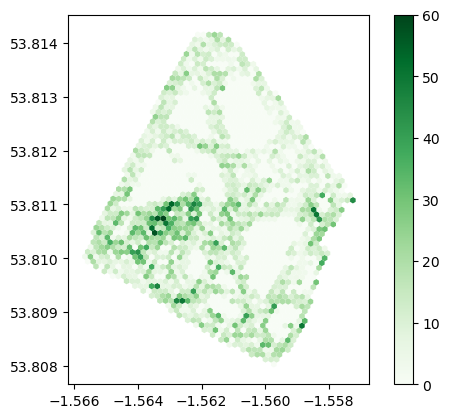

In [12]:
foliage_results.plot(column="mid_level_0.5-2", cmap='Greens', legend=True)

<Axes: >

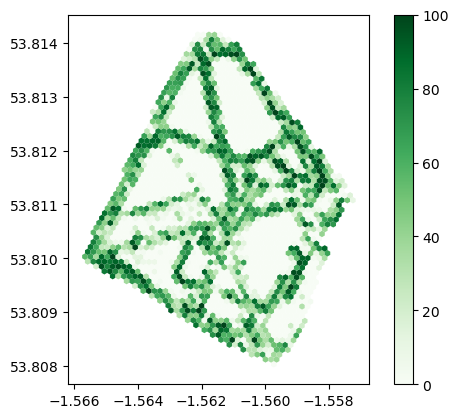

In [13]:
foliage_results.plot(column="tall_2+", cmap='Greens', legend=True)

Now testing on another site - the smallest Leeds park, to use as an example test case

`park_vga.workflow.find_smallest_park_id(boundaries_file)`



In [14]:
test_park = park_vga.workflow.find_smallest_park_id(boundaries_file)

In [15]:
test_park

(None, 'LEEDS_667fb1455fba', 1047)

In [16]:
test_park[2]

1047

In [17]:
results = park_vga.workflow.workflow_eng(boundaries_file, test_park[2], lidar_dtm, lidar_dsm, output_path)

Output directory already exists at ../../outputs/TESTWORKFLOW
Park ID: LEEDS_667fb1455fba
Park ID for file name: leeds_667fb1455fba
Define park grid.
Load park tiles
Finding tile names from park geometry
Calculating grid refs
[(429357.02794963564, 433285.16368247103), (429357.02794963564, 433327.9544390665), (429314.40468138934, 433327.9544390665), (429314.40468138934, 433285.16368247103)]
Grid refs for corners: ['SE23se', 'SE23se', 'SE23se', 'SE23se']
Tile name(s): {'SE23se'} 
Finding file paths for these tiles
Paths found: 
DTM paths: ['/Volumes/Extreme SSD/DTM/SE23se_DTM_2m.tif'] 
DSM paths: ['/Volumes/Extreme SSD/FZ_DSM/SE23se_FZ_DSM_2m.tif']
Files found for park 1
Created 18 pointy-top hexagons (10m vertical spacing)
Loading 1 DSM and 1 DTM files
DSM valid pixels: 6250000 of 6250000 (100.0%)
DTM valid pixels: 6250000 of 6250000 (100.0%)
Output shape: (22, 22), Height range: -0.0m to 35.4m
Start calculating visibility. This will take a few mins
Calculating visibility for 18 points


In [18]:
visibility_results = gpd.read_file(f"{output_path}/TESTINGWORKFLOW_visibility_results_park_leeds_667fb1455fba.geojson")

foliage_results = gpd.read_file(f"{output_path}/TESTINGWORKFLOW_foliage_results_park_leeds_667fb1455fba.geojson")

In [22]:
visibility_results.head()

,visible_points,total_points,visibility_pct,geometry
0,7,17,41.176471,"POLYGON ((-1.55603 53.79528, -1.55612 53.79531..."


<Axes: >

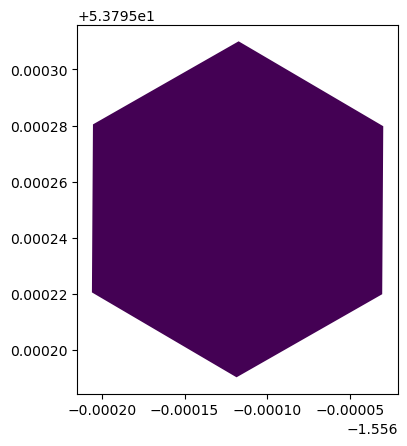

In [21]:
visibility_results.plot(column="visibility_pct", )

In [23]:
foliage_results.head()

,geometry
